In [2]:
import pathlib, warnings, json
from collections import Counter

import numpy as np
import scipy.sparse as sp
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")

ROOT      = pathlib.Path("..").resolve()
ARTIFACTS = ROOT / "artifacts"
MODELS    = ROOT / "models"

RANDOM_STATE    = 42
TEST_SIZE       = 0.20
TARGET_MACRO_F1 = 0.62
TARGET_TOP3_ACC = 0.80


In [3]:
# Load exactly the same files notebook 2 used
X             = joblib.load(ARTIFACTS / "X.joblib")
y             = joblib.load(ARTIFACTS / "y.joblib")
feature_vocab = joblib.load(ARTIFACTS / "feature_vocab.joblib")
model         = joblib.load(MODELS    / "model.joblib")

all_technique_ids = sorted(feature_vocab, key=feature_vocab.get)

print(f"X shape      : {X.shape}")
print(f"Classes      : {len(set(y))}")
print(f"Features     : {len(all_technique_ids)}")
print(f"Model type   : {type(model).__name__}")


X shape      : (5040, 204)
Classes      : 168
Features     : 204
Model type   : VotingClassifier


In [4]:
# Mirror notebook 2 split logic precisely — same random_state, same TEST_SIZE
count_by_class = Counter(y)
single_classes = {c for c, n in count_by_class.items() if n < 2}
multi_mask     = np.array([label not in single_classes for label in y])

idx_single = np.where(~multi_mask)[0]
idx_multi  = np.where(multi_mask)[0]

X_multi = X[idx_multi]
y_multi = np.array(y)[idx_multi]

_, X_test, _, y_test = train_test_split(
    X_multi, y_multi,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_multi,
)

print(f"Test samples : {X_test.shape[0]}")
print(f"Single-sample classes (train-only) : {len(single_classes)}")
print(f"Classes in test set : {len(set(y_test.tolist()))}")
print()
print("⚠  Single-sample classes never appear in test — known limitation.")


Test samples : 1008
Single-sample classes (train-only) : 0
Classes in test set : 168

⚠  Single-sample classes never appear in test — known limitation.


In [5]:
# X_test is already dense (notebook 2 used np.vstack → dense)
X_test_dense = X_test.toarray() if sp.issparse(X_test) else X_test

y_pred  = model.predict(X_test_dense)
y_proba = model.predict_proba(X_test_dense)

print(f"Predictions shape : {y_pred.shape}")
print(f"Proba shape       : {y_proba.shape}")
print(f"Sample predictions: {list(y_pred[:5])}")


Predictions shape : (1008,)
Proba shape       : (1008, 168)
Sample predictions: [np.str_('admin@338'), np.str_('Leviathan'), np.str_('Malteiro'), np.str_('Silent Librarian'), np.str_('Sandworm Team')]


In [6]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro", zero_division=0
)

print("=" * 52)
print(f"  Macro Precision : {precision:.4f}")
print(f"  Macro Recall    : {recall:.4f}")
print(f"  Macro F1        : {f1:.4f}  (target >= {TARGET_MACRO_F1})")
print("=" * 52)
print("  " + ("✓ F1 threshold met" if f1 >= TARGET_MACRO_F1 else "✗ Below threshold — see tuning block"))


  Macro Precision : 0.9523
  Macro Recall    : 0.9435
  Macro F1        : 0.9431  (target >= 0.62)
  ✓ F1 threshold met


In [7]:
# model.classes_ gives the ordered class labels for predict_proba columns
classes = model.classes_

top3_correct = 0
for i, true_label in enumerate(y_test):
    # argsort proba descending, take top 3 column indices
    top3_col_idx = np.argsort(y_proba[i])[::-1][:3]
    top3_labels  = [classes[j] for j in top3_col_idx]
    if true_label in top3_labels:
        top3_correct += 1

top3_acc = top3_correct / len(y_test)

print(f"Top-3 accuracy : {top3_acc:.4f}  (target >= {TARGET_TOP3_ACC})")
print("  " + ("✓ Top-3 threshold met" if top3_acc >= TARGET_TOP3_ACC else "✗ Below threshold"))


Top-3 accuracy : 0.9861  (target >= 0.8)
  ✓ Top-3 threshold met


In [8]:
# Sort unique test labels for a clean report
labels_in_test = sorted(set(y_test.tolist()))

report = classification_report(
    y_test, y_pred,
    labels=labels_in_test,
    zero_division=0,
)
print(report)


                      precision    recall  f1-score   support

            APT-C-36       1.00      1.00      1.00         6
                APT1       1.00      1.00      1.00         6
               APT12       0.86      1.00      0.92         6
               APT18       0.67      1.00      0.80         6
               APT19       1.00      0.83      0.91         6
               APT28       1.00      1.00      1.00         6
               APT29       1.00      1.00      1.00         6
                APT3       1.00      1.00      1.00         6
               APT32       1.00      1.00      1.00         6
               APT33       1.00      1.00      1.00         6
               APT37       1.00      1.00      1.00         6
               APT38       1.00      1.00      1.00         6
               APT39       1.00      1.00      1.00         6
               APT41       1.00      1.00      1.00         6
               APT42       1.00      1.00      1.00         6
       

In [9]:
# Identify chronically failing groups (F1 == 0)
report_dict = classification_report(
    y_test, y_pred,
    labels=labels_in_test,
    zero_division=0,
    output_dict=True,
)
failing = [
    name for name in labels_in_test
    if report_dict.get(name, {}).get("f1-score", 0.0) == 0.0
]
print(f"Groups with F1 = 0 on test set : {len(failing)}")
for g in failing[:15]:
    print(f"  - {g}")
if len(failing) > 15:
    print(f"  ... and {len(failing)-15} more")


Groups with F1 = 0 on test set : 0


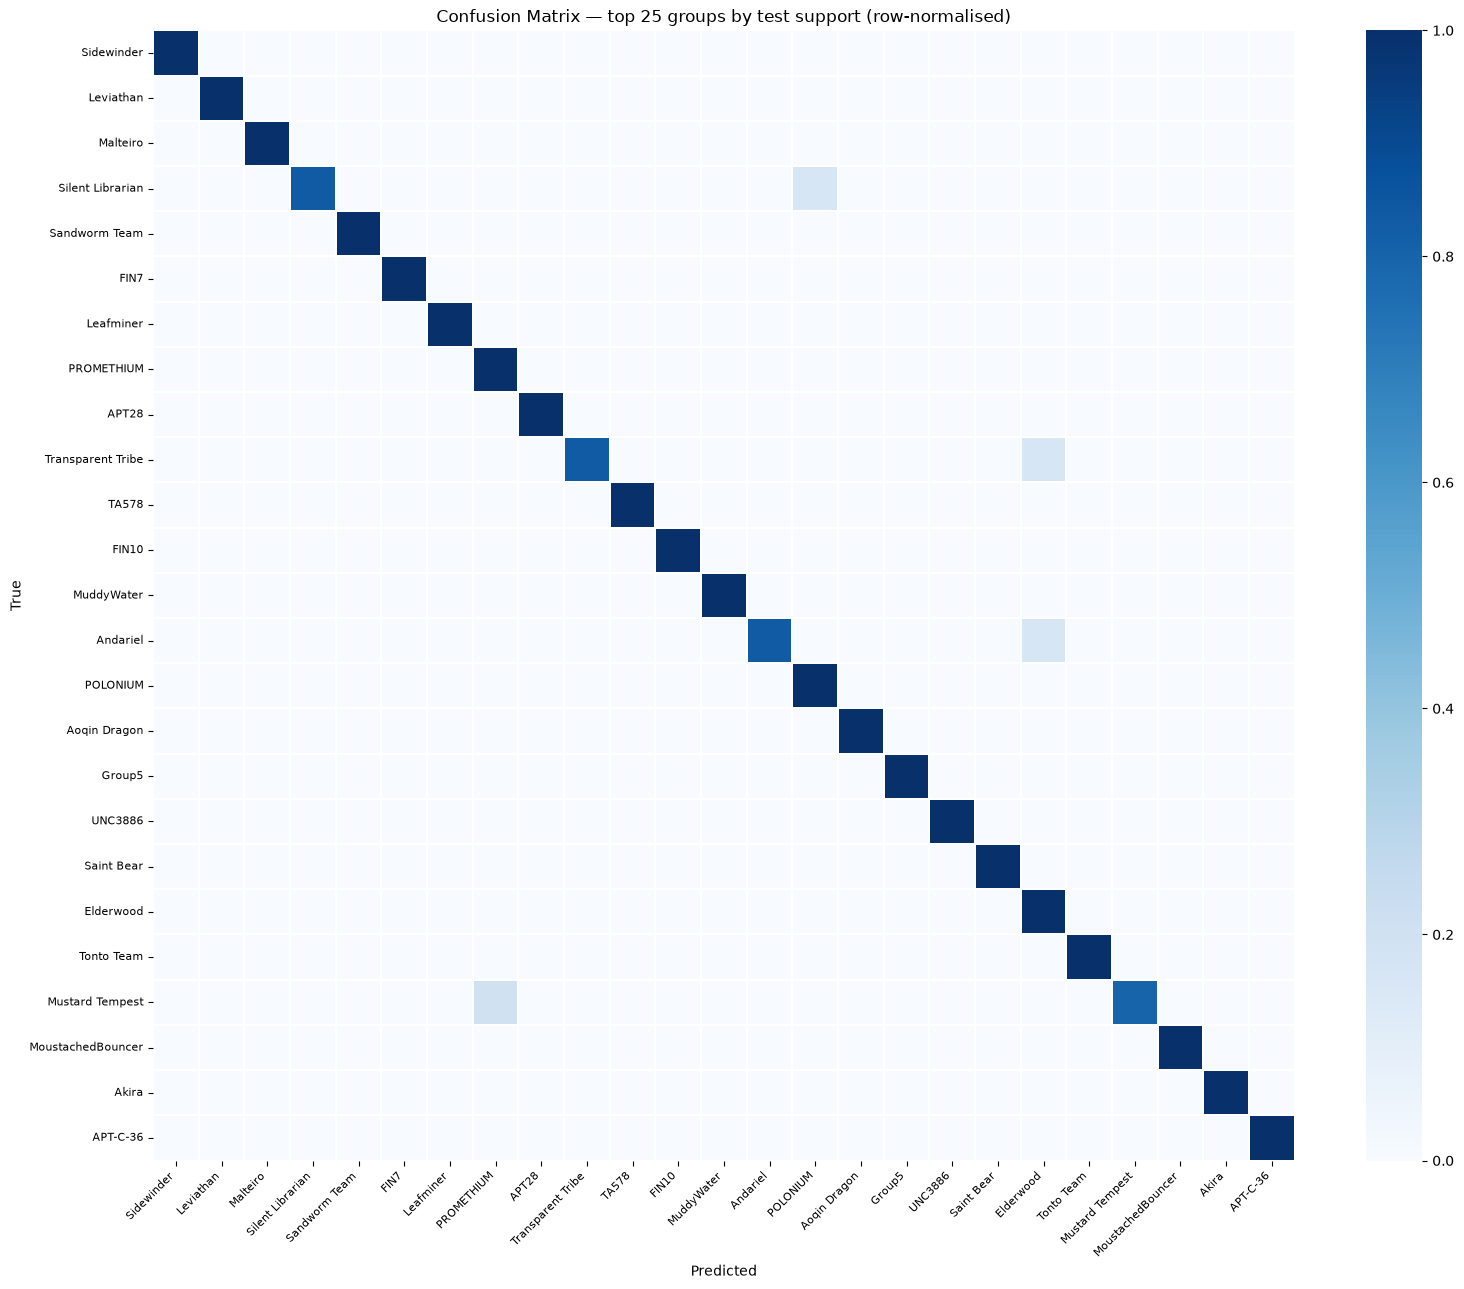

Saved → artifacts/confusion_matrix.png


In [10]:
# Pick top 25 groups that appear most in the test set
test_support = Counter(y_test.tolist())
top25_names  = [name for name, _ in test_support.most_common(25)]

mask   = np.isin(y_test, top25_names)
y_t25  = y_test[mask]
y_p25  = y_pred[mask]

cm      = confusion_matrix(y_t25, y_p25, labels=top25_names)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    cm_norm, annot=False,
    xticklabels=top25_names, yticklabels=top25_names,
    cmap="Blues", ax=ax, linewidths=0.3, linecolor="white",
)
ax.set_title("Confusion Matrix — top 25 groups by test support (row-normalised)", fontsize=12)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(ARTIFACTS / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → artifacts/confusion_matrix.png")


In [11]:
import shap

# Pull the XGBoost sub-estimator from the VotingClassifier
xgb_model = model.named_estimators_["xgb"]

print("Computing SHAP values (TreeExplainer on XGBoost base)...")
# NOTE: 'interventional' feature_perturbation requires categorical support not available in XGBoost hist;
# use 'tree_path_dependent' which is the correct default for tree models.
explainer   = shap.TreeExplainer(xgb_model, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X_test_dense)
# shap_values shape: (n_samples, n_features, n_classes) in shap >= 0.40
print(f"SHAP array shape : {np.array(shap_values).shape}")
print("Done ✓")


Computing SHAP values (TreeExplainer on XGBoost base)...
SHAP array shape : (1008, 204, 168)
Done ✓


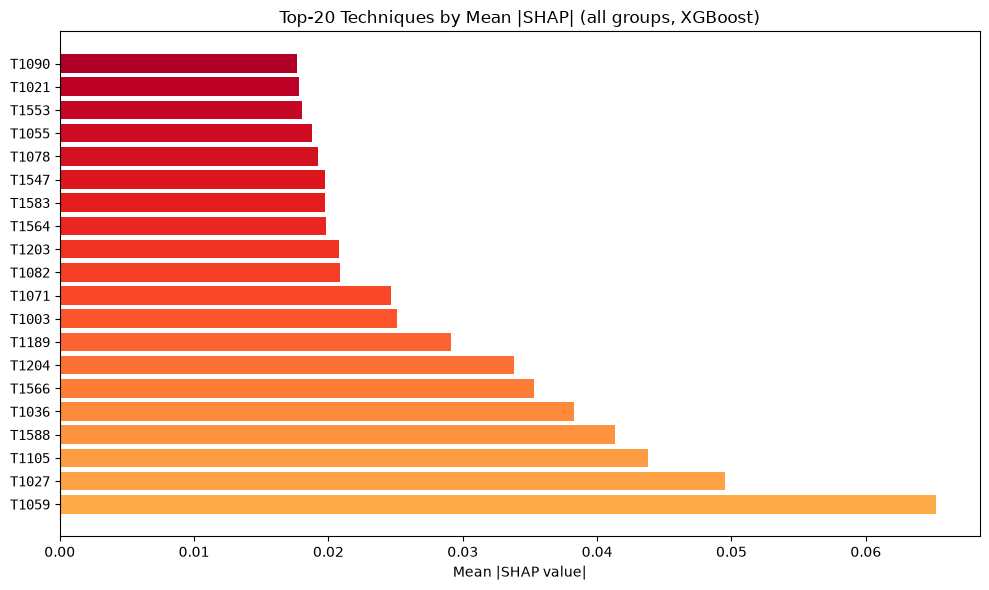

Saved → artifacts/shap_importance.png


In [12]:
# Mean |SHAP| per technique across all classes and all test samples
shap_arr = np.array(shap_values)  # shape: (n_samples, n_features, n_classes)

# Determine correct axis based on actual shape
if shap_arr.ndim == 3:
    # New shap >= 0.40: (n_samples, n_features, n_classes) → average over samples & classes
    mean_abs_shap = np.abs(shap_arr).mean(axis=(0, 2))  # → (n_features,)
else:
    # Legacy shap: shap_values is a list of (n_samples, n_features) arrays per class
    mean_abs_shap = np.abs(shap_arr).mean(axis=(0, 1))  # → (n_features,)

assert mean_abs_shap.shape[0] == len(all_technique_ids), \
    f"SHAP shape mismatch: {mean_abs_shap.shape[0]} vs {len(all_technique_ids)} features"

top_k    = 20
top_idx  = np.argsort(mean_abs_shap)[::-1][:top_k]
top_tids = [all_technique_ids[i] for i in top_idx]
top_vals = mean_abs_shap[top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, top_k))
ax.barh(range(top_k), top_vals[::-1], color=colors[::-1])
ax.set_yticks(range(top_k))
ax.set_yticklabels(top_tids[::-1], fontsize=10, fontfamily="monospace")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top-20 Techniques by Mean |SHAP| (all groups, XGBoost)", fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ARTIFACTS / "shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → artifacts/shap_importance.png")


In [13]:
shap_table = [
    {"technique_id": all_technique_ids[i], "mean_abs_shap": float(mean_abs_shap[i])}
    for i in np.argsort(mean_abs_shap)[::-1]
]
with open(ARTIFACTS / "shap_importance.json", "w") as f:
    json.dump(shap_table[:50], f, indent=2)
print("Saved → artifacts/shap_importance.json (top 50)")


Saved → artifacts/shap_importance.json (top 50)


In [14]:
print("Threshold review:")
print(f"  Macro F1  : {f1:.4f}  {'✓' if f1 >= TARGET_MACRO_F1 else '✗'}")
print(f"  Top-3 acc : {top3_acc:.4f}  {'✓' if top3_acc >= TARGET_TOP3_ACC else '✗'}")
print()
print("Strategies if below threshold:")
print("  A) Adjust SMOTE k — try k=1 in notebook 2 for very sparse classes")
print()
print("  B) Tune ensemble weights — try [4,1,1] or [3,2,1] in VotingClassifier")
print()
print("  C) Increase Optuna trials to 120+ for broader hyperparameter coverage")


Threshold review:
  Macro F1  : 0.9431  ✓
  Top-3 acc : 0.9861  ✓

Strategies if below threshold:
  A) Adjust SMOTE k — try k=1 in notebook 2 for very sparse classes

  B) Tune ensemble weights — try [4,1,1] or [3,2,1] in VotingClassifier

  C) Increase Optuna trials to 120+ for broader hyperparameter coverage


In [15]:
eval_summary = {
    "eval_method"       : "held_out_test_set",
    "macro_precision"   : float(precision),
    "macro_recall"      : float(recall),
    "macro_f1"          : float(f1),
    "top3_accuracy"     : float(top3_acc),
    "n_test_samples"    : int(X_test.shape[0]),
    "n_classes_in_test" : int(len(set(y_test.tolist()))),
    "n_failing_groups"  : len(failing),
    "failing_groups"    : failing,
    "target_macro_f1"   : TARGET_MACRO_F1,
    "target_top3_acc"   : TARGET_TOP3_ACC,
    "note"              : f"{len(single_classes)} single-sample classes excluded from test (train-only)",
}
with open(ARTIFACTS / "eval_summary.json", "w") as f:
    json.dump(eval_summary, f, indent=2)

print("Saved → artifacts/eval_summary.json")
print()
print("=" * 52)
print("  Phase 4 complete — Evaluation & SHAP")
print("  Next → 04_inference_function.ipynb")
print("=" * 52)


Saved → artifacts/eval_summary.json

  Phase 4 complete — Evaluation & SHAP
  Next → 04_inference_function.ipynb
